# Spotify Songs 2023 - Exploratory Data Analysis

## Research Question
Which features are most strongly associated with Spotify streaming success in 2023?

## Step 1: Define Research Question and Modeling Goal

The purpose of this project is to analyze which factors are most important in explaining and predicting Spotify streaming performance in 2023.

The target variable is `streams`, which represents the number of times a song was streamed on Spotify. Since streaming numbers are usually highly skewed, I will use a log-transformed version of streams, called `log_streams`, as the target variable.

Instead of only focusing on audio features, this improved model includes multiple types of predictors:

- Audio features, such as danceability, energy, valence, acousticness, and speechiness.
- Exposure features, such as Spotify playlists, Spotify charts, Apple playlists, and Deezer playlists.
- Song information, such as release year, release month, release day, and artist count.
- Categorical features, such as key and mode.
- Artist-related information, such as artist frequency.

The goal is to first train an XGBoost regression model using all available features. Then, I will use feature importance to identify which variables contribute most to streaming performance. After that, I will rebuild the model using only the most important features to evaluate whether a smaller feature set can still explain streaming performance effectively.

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
df = pd.read_csv("spotify-2023.csv", encoding="latin1")

df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,Unnamed: 24,Unnamed: 25
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,Major,80,89,83,31,0,8,4.0,NaN,NaN
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,Major,71,61,74,7,0,10,4.0,NaN,NaN
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,Major,51,32,53,17,0,31,6.0,NaN,NaN
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,Major,55,58,72,11,0,11,15.0,NaN,NaN
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,Minor,65,23,80,14,63,11,6.0,NaN,NaN


## Step 2: Data Inspection and Target Variable Cleaning

Before building the model, it is important to inspect the dataset and clean the target variable.

The target variable in this project is `streams`, which represents the number of Spotify streams for each song. However, the `streams` column may contain formatting issues, such as commas or non-numeric values, so it must first be converted into a numerical format.

In addition, streaming data is usually highly skewed because a small number of songs receive extremely large numbers of streams, while most songs receive relatively fewer streams. This type of distribution can negatively affect regression performance.

To reduce skewness and stabilize variance, I will create a new variable called `log_streams` using a log transformation.

This step includes:

1. Inspecting the dataset structure.
2. Checking missing values and data types.
3. Converting `streams` into a numeric variable.
4. Creating the `log_streams` target variable.
5. Visualizing the distribution before and after log transformation.

In [115]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   track_name            947 non-null    str    
 1   artist(s)_name        947 non-null    str    
 2   artist_count          947 non-null    str    
 3   released_year         947 non-null    str    
 4   released_month        947 non-null    int64  
 5   released_day          947 non-null    int64  
 6   in_spotify_playlists  947 non-null    int64  
 7   in_spotify_charts     947 non-null    int64  
 8   streams               947 non-null    str    
 9   in_apple_playlists    947 non-null    int64  
 10  in_apple_charts       947 non-null    int64  
 11  in_deezer_playlists   947 non-null    str    
 12  in_deezer_charts      947 non-null    int64  
 13  in_shazam_charts      897 non-null    str    
 14  bpm                   946 non-null    str    
 15  key                   854 non-null

In [116]:
df.describe()

,released_month,released_day,in_spotify_playlists,in_spotify_charts,in_apple_playlists,in_apple_charts,in_deezer_charts,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,Unnamed: 24,Unnamed: 25
count,947.000000,947.000000,947.00000,9.470000e+02,9.470000e+02,9.470000e+02,947.000000,947.000000,947.000000,947.000000,947.000000,938.000000,6.000000,3.000000
mean,12.487856,55.462513,5165.80359,3.934486e+06,2.087421e+06,4.791879e+05,3.040127,63.812038,27.014784,1.964097,18.249208,9.984009,14.000000,28.666667
std,113.368791,572.092222,7927.42516,5.153793e+07,4.158526e+07,8.950992e+06,7.701245,17.117321,26.088761,9.239632,13.872311,9.772370,11.313708,20.033306
min,1.000000,1.000000,0.00000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,4.000000,6.000000
25%,3.000000,6.000000,848.00000,0.000000e+00,1.300000e+01,7.000000e+00,0.000000,53.000000,5.000000,0.000000,9.000000,4.000000,5.250000,21.000000
50%,6.000000,13.000000,2129.00000,3.000000e+00,3.400000e+01,3.900000e+01,0.000000,66.000000,18.000000,0.000000,12.000000,6.000000,9.500000,36.000000
75%,9.000000,22.000000,5486.00000,1.700000e+01,8.900000e+01,8.700000e+01,2.000000,77.000000,43.000000,0.000000,24.000000,11.000000,23.500000,40.000000
max,2022.000000,14311.000000,52898.00000,1.062346e+09,1.061967e+09,1.877016e+08,89.000000,97.000000,97.000000,91.000000,97.000000,64.000000,29.000000,44.000000


In [117]:
df.isnull().sum()

track_name                0
artist(s)_name            0
artist_count              0
released_year             0
released_month            0
released_day              0
in_spotify_playlists      0
in_spotify_charts         0
streams                   0
in_apple_playlists        0
in_apple_charts           0
in_deezer_playlists       0
in_deezer_charts          0
in_shazam_charts         50
bpm                       1
key                      93
mode                      0
danceability_%            0
valence_%                 0
energy_%                  0
acousticness_%            0
instrumentalness_%        0
liveness_%                0
speechiness_%             9
Unnamed: 24             941
Unnamed: 25             944
dtype: int64

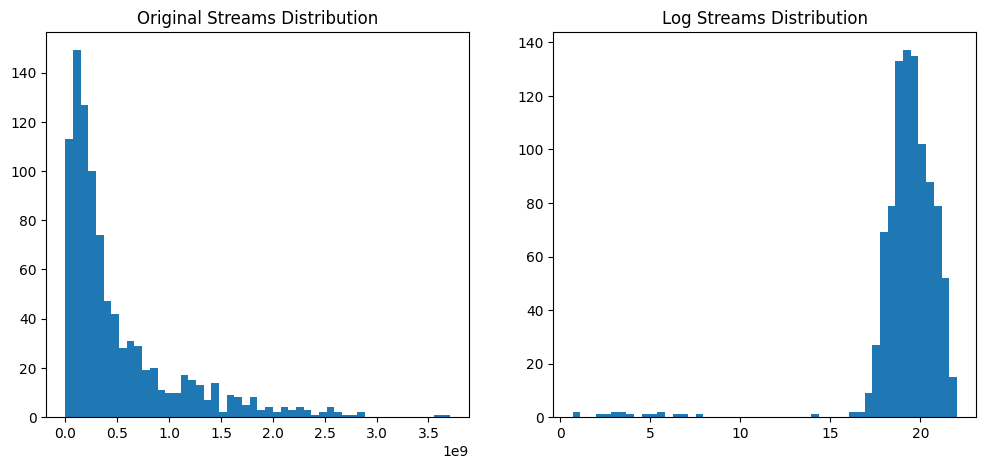

In [118]:
df['streams'] = pd.to_numeric(
    df['streams'],
    errors='coerce'
)
df = df.dropna(subset=['streams'])
df['log_streams'] = np.log1p(df['streams'])
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df['streams'], bins=50)
plt.title('Original Streams Distribution')

plt.subplot(1,2,2)
plt.hist(df['log_streams'], bins=50)
plt.title('Log Streams Distribution')

plt.show()

## Step 3: Feature Selection and Feature Engineering

After cleaning the target variable, the next step is to prepare the predictor variables for modeling.

In this project, I include several different types of features:

### 1. Audio Features
These variables describe the musical characteristics of each song, such as danceability, energy, valence, and acousticness.

### 2. Exposure Features
These variables measure how much exposure a song receives on streaming platforms and charts, such as Spotify playlists and Apple playlists.

### 3. Song Information Features
These variables describe general information about the song, including release date and artist count.

### 4. Categorical Features
The variables `key` and `mode` are categorical variables. Since XGBoost cannot directly process text categories, they will later be converted into dummy variables.

### 5. Artist-Related Features
The dataset contains artist names, but directly using artist names would create too many categories and may lead to overfitting.

Instead, I create a new variable called `artist_frequency`, which measures how often the main artist appears in the dataset. This feature can approximately represent artist popularity or artist exposure.

This step includes:

1. Selecting useful features.
2. Creating artist-related features.
3. Converting numerical columns into numeric format.
4. Building the modeling dataset.

In [119]:
audio_features = [
    'danceability_%',
    'energy_%',
    'valence_%',
    'acousticness_%',
    'instrumentalness_%',
    'liveness_%',
    'speechiness_%'
]

exposure_features = [
    'in_spotify_playlists',
    'in_spotify_charts',
    'in_apple_playlists',
    'in_apple_charts',
    'in_deezer_playlists',
    'in_deezer_charts'
]

song_features = [
    'artist_count',
    'released_year',
    'released_month',
    'released_day'
]

categorical_features = [
    'key',
    'mode'
]
df['main_artist'] = df['artist(s)_name'].str.split(',').str[0]

artist_counts = df['main_artist'].value_counts()

df['artist_frequency'] = df['main_artist'].map(artist_counts)

In [120]:
all_features = (
    audio_features +
    exposure_features +
    song_features +
    categorical_features +
    ['artist_frequency']
)
numerical_features = (
    audio_features +
    exposure_features +
    song_features +
    ['artist_frequency']
)

for col in numerical_features:
    df[col] = pd.to_numeric(df[col], errors='coerce')
model_df = df[all_features + ['log_streams']].dropna()

In [121]:
model_df.head()

,danceability_%,energy_%,valence_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,in_spotify_playlists,in_spotify_charts,in_apple_playlists,...,in_deezer_playlists,in_deezer_charts,artist_count,released_year,released_month,released_day,key,mode,artist_frequency,log_streams
0,80.0,83,89.0,31,0,8,4.0,553,147,43,...,45.0,10,2.0,2023.0,7,14,B,Major,1,18.766974
1,71.0,74,61.0,7,0,10,4.0,1474,48,48,...,58.0,14,1.0,2023.0,3,23,C#,Major,1,18.711231
2,51.0,53,32.0,17,0,31,6.0,1397,113,94,...,91.0,14,1.0,2023.0,6,30,F,Major,7,18.757181
3,55.0,72,58.0,11,0,11,15.0,7858,100,116,...,125.0,12,1.0,2019.0,8,23,A,Major,36,20.501173
4,65.0,80,23.0,14,63,11,6.0,3133,50,84,...,87.0,15,1.0,2023.0,5,18,A,Minor,24,19.530023


In [122]:
model_df.info()

<class 'pandas.DataFrame'>
Index: 763 entries, 0 to 946
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   danceability_%        763 non-null    float64
 1   energy_%              763 non-null    int64  
 2   valence_%             763 non-null    float64
 3   acousticness_%        763 non-null    int64  
 4   instrumentalness_%    763 non-null    int64  
 5   liveness_%            763 non-null    int64  
 6   speechiness_%         763 non-null    float64
 7   in_spotify_playlists  763 non-null    int64  
 8   in_spotify_charts     763 non-null    int64  
 9   in_apple_playlists    763 non-null    int64  
 10  in_apple_charts       763 non-null    int64  
 11  in_deezer_playlists   763 non-null    float64
 12  in_deezer_charts      763 non-null    int64  
 13  artist_count          763 non-null    float64
 14  released_year         763 non-null    float64
 15  released_month        763 non-null    i

## Step 4: Encode Categorical Variables and Split the Data

After preparing the modeling dataset, the next step is to separate the predictor variables from the target variable.

The predictor variables are stored in `X`, and the target variable is stored in `y`.

Because `key` and `mode` are categorical variables, they cannot be directly used by XGBoost in their original text format. Therefore, I use one-hot encoding to convert them into numerical dummy variables.

After encoding the categorical variables, I split the dataset into a training set and a testing set. The training set is used to train the XGBoost model, while the testing set is used to evaluate how well the model performs on unseen data.

This step includes:

1. Separating `X` and `y`.
2. Encoding categorical variables with dummy variables.
3. Splitting the data into training and testing sets.

In [123]:
X = model_df[all_features]
y = model_df['log_streams']
X = pd.get_dummies(
    X,
    columns=['key', 'mode'],
    drop_first=True
)
X.head()

,danceability_%,energy_%,valence_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,in_spotify_playlists,in_spotify_charts,in_apple_playlists,...,key_B,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,mode_Minor
0,80.0,83,89.0,31,0,8,4.0,553,147,43,...,True,False,False,False,False,False,False,False,False,False
1,71.0,74,61.0,7,0,10,4.0,1474,48,48,...,False,True,False,False,False,False,False,False,False,False
2,51.0,53,32.0,17,0,31,6.0,1397,113,94,...,False,False,False,False,False,True,False,False,False,False
3,55.0,72,58.0,11,0,11,15.0,7858,100,116,...,False,False,False,False,False,False,False,False,False,False
4,65.0,80,23.0,14,63,11,6.0,3133,50,84,...,False,False,False,False,False,False,False,False,False,True


In [124]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [125]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (610, 29)
X_test shape: (153, 29)
y_train shape: (610,)
y_test shape: (153,)


## Step 5: Train the Initial XGBoost Model

After preparing the dataset, I can now train the first XGBoost regression model using all available features.

XGBoost is an ensemble learning method based on gradient boosting. Instead of building only one decision tree, XGBoost sequentially builds many trees, where each new tree attempts to reduce the prediction errors made by the previous trees.

In this project, the purpose of the initial model is not only to make predictions, but also to identify which variables are most important for explaining Spotify streaming performance.

At this stage, I use a relatively simple XGBoost model with basic hyperparameters:

- `n_estimators`: controls the number of trees.
- `max_depth`: controls the complexity of each tree.
- `learning_rate`: controls how strongly each tree updates the model.

After training the model, I evaluate its performance using:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² (Coefficient of Determination)

These metrics help measure how accurately the model predicts streaming performance on unseen test data.

In [126]:
model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)
model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [127]:
y_pred = model.predict(X_test)

In [128]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.39874387208559536
RMSE: 0.531563913556157
R²: 0.7390269379178971


## Step 6: Analyze Feature Importance

After training the initial XGBoost model, the next step is to analyze feature importance.

Feature importance measures how much each variable contributes to reducing prediction error in the XGBoost model. Features that are used more frequently and create larger improvements in prediction accuracy are assigned higher importance scores.

The purpose of this step is to identify which factors have the strongest influence on Spotify streaming performance.

Instead of manually assuming which variables are important, XGBoost automatically evaluates how useful each feature is during the boosting process.

This analysis helps answer the main research question:

Which variables contribute most to explaining streaming performance in 2023?

In [129]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)
importance_df.head(15)

,Feature,Importance
7,in_spotify_playlists,0.326694
2,valence_%,0.082031
12,in_deezer_charts,0.076220
18,key_A#,0.071963
0,danceability_%,0.056589
14,released_year,0.051970
11,in_deezer_playlists,0.049448
8,in_spotify_charts,0.038183
15,released_month,0.032167
9,in_apple_playlists,0.023165


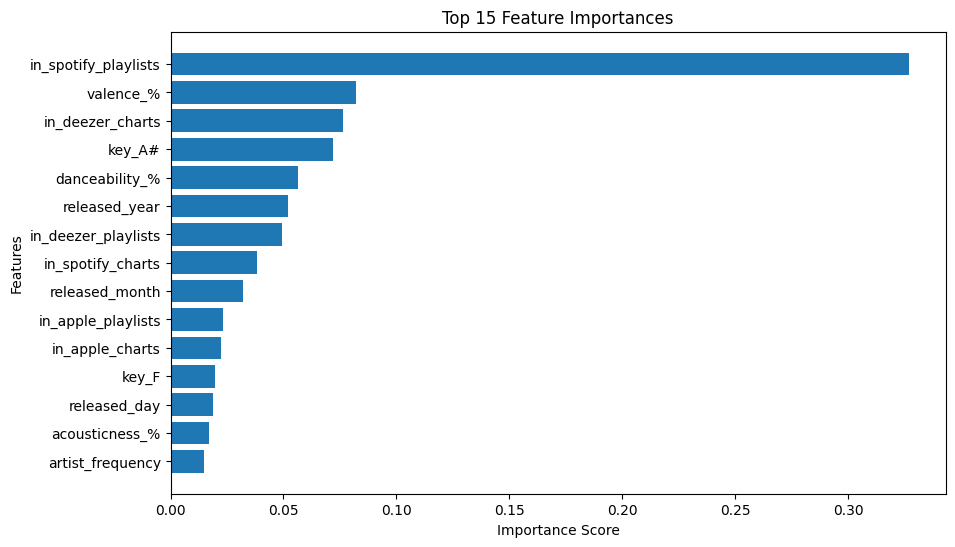

In [130]:
top_15 = importance_df.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_15['Feature'],
    top_15['Importance']
)

plt.gca().invert_yaxis()

plt.title('Top 15 Feature Importances')

plt.xlabel('Importance Score')

plt.ylabel('Features')

plt.show()

The feature importance analysis suggests that exposure-related variables are the strongest predictors of streaming performance.

Among all variables, `in_spotify_playlists` had by far the highest importance score, indicating that playlist exposure plays a major role in increasing streaming counts.

Although some audio features, such as danceability, contributed to the model, their importance scores were much lower than exposure variables.

Interestingly, some categorical variables such as musical key also appeared important, although these relationships may reflect dataset-specific associations rather than direct causal effects.

Overall, the results suggest that streaming success is driven more by platform visibility and exposure than by audio characteristics alone.

## Step 7: Rebuild the Model Using Important Features

After analyzing feature importance, the next step is to rebuild the XGBoost model using only the most important features.

The purpose of this step is to perform feature selection. Instead of using all available variables, I select the features with the highest importance scores and evaluate whether a smaller feature set can still achieve strong prediction performance.

Feature selection can improve:

- Model interpretability
- Computational efficiency
- Generalization ability
- Reduction of unnecessary noise

In this step, I select the top important features identified from the previous feature importance analysis and retrain the XGBoost model.

Then, I compare the new model performance with the original full-feature model using:

- MAE
- RMSE
- R²

This comparison helps evaluate whether the most important variables alone are sufficient to explain Spotify streaming performance.

In [131]:
top_features = importance_df.head(10)['Feature'].tolist()

top_features

['in_spotify_playlists',
 'valence_%',
 'in_deezer_charts',
 'key_A#',
 'danceability_%',
 'released_year',
 'in_deezer_playlists',
 'in_spotify_charts',
 'released_month',
 'in_apple_playlists']

In [132]:
X_selected = X[top_features]

In [133]:
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42
)

In [134]:
selected_model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)
selected_model.fit(
    X_train_selected,
    y_train_selected
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [135]:
y_pred_selected = selected_model.predict(
    X_test_selected
)

In [136]:
selected_mae = mean_absolute_error(
    y_test_selected,
    y_pred_selected
)

selected_rmse = np.sqrt(
    mean_squared_error(
        y_test_selected,
        y_pred_selected
    )
)

selected_r2 = r2_score(
    y_test_selected,
    y_pred_selected
)

print("Selected Features MAE:", selected_mae)
print("Selected Features RMSE:", selected_rmse)
print("Selected Features R²:", selected_r2)

Selected Features MAE: 0.3801457673995448
Selected Features RMSE: 0.5058364892080202
Selected Features R²: 0.7636775338586977


## Step 7 Result Interpretation

After rebuilding the XGBoost model using only the top important features, the model achieved an R² score of approximately 0.764.

Compared with the full-feature model, the selected-feature model performs slightly worse, but it still explains a large portion of the variation in `log_streams`.

This suggests that most of the model's predictive power comes from a smaller group of important variables, especially exposure-related features such as playlist and chart variables.

Although removing less important features reduces some predictive accuracy, the selected-feature model is easier to interpret and still maintains strong performance.

## Step 8: Compare the Full Model and the Selected-Feature Model

After training both models, the next step is to compare their performance.

The first model used all available features, including audio features, exposure variables, categorical variables, and artist-related variables.

The second model used only the most important features selected from the feature importance analysis.

The purpose of this comparison is to evaluate whether a smaller and more interpretable feature set can still maintain strong prediction performance.

The comparison focuses on three evaluation metrics:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² (Coefficient of Determination)

By comparing these metrics, I can evaluate the tradeoff between model complexity and prediction accuracy.

In [137]:
comparison_df = pd.DataFrame({
    'Model': [
        'Full Feature Model',
        'Selected Feature Model'
    ],
    
    'MAE': [
        mae,
        selected_mae
    ],
    
    'RMSE': [
        rmse,
        selected_rmse
    ],
    
    'R²': [
        r2,
        selected_r2
    ]
})

comparison_df

,Model,MAE,RMSE,R²
0,Full Feature Model,0.398744,0.531564,0.739027
1,Selected Feature Model,0.380146,0.505836,0.763678


The selected-feature model achieved better performance than the full-feature model.

Although the full model included all available variables, some low-importance features may have introduced additional noise and reduced the model's ability to generalize.

After removing less important variables, the selected-feature model achieved lower MAE and RMSE values, while also improving the R² score.

This suggests that a smaller set of highly informative features is sufficient to explain streaming performance effectively.

## Step 9: Final Discussion and Conclusion

The purpose of this project was to analyze which factors are most important in explaining and predicting Spotify streaming performance in 2023.

To answer this question, I built multiple XGBoost regression models using different types of variables, including:

- Audio features
- Exposure variables
- Song information
- Categorical variables
- Artist-related features

The results showed that exposure-related variables were the strongest predictors of streaming performance.

Among all variables, `in_spotify_playlists` consistently had the highest feature importance score. This suggests that playlist exposure plays a major role in increasing streaming counts. Songs that appear in more playlists are more likely to be discovered by users, leading to higher streaming performance.

In contrast, audio features such as danceability, valence, and acousticness contributed to the model, but their importance scores were generally much lower than exposure variables. This indicates that musical characteristics alone are not sufficient to explain streaming success.

The project also included categorical variables such as `key` and `mode`, as well as an artist-related feature called `artist_frequency`. Some categorical variables appeared important in certain models, but these relationships may reflect dataset-specific associations rather than direct causal effects.

After analyzing feature importance, I rebuilt the model using only the most important variables. Interestingly, the selected-feature model performed better than the full-feature model. The selected-feature model achieved lower MAE and RMSE values while also improving the R² score.

This result suggests that including too many low-importance variables may introduce noise and reduce model generalization ability. By removing less useful variables, the model became simpler and more effective.

Overall, the project suggests that Spotify streaming success is driven more by platform exposure and visibility than by audio characteristics alone.

### Limitations

This project still has several limitations:

- The dataset may not fully represent all Spotify songs.
- Feature importance does not necessarily imply causation.
- Artist popularity was only approximated using artist frequency.
- External factors such as marketing, social media trends, and viral content were not included.

### Future Improvements

Possible future improvements include:

- Using real artist popularity metrics.
- Including social media or TikTok data.
- Testing other ensemble models such as LightGBM or Random Forest.
- Using cross-validation and hyperparameter tuning for further optimization.
- Exploring SHAP values for better model interpretability.

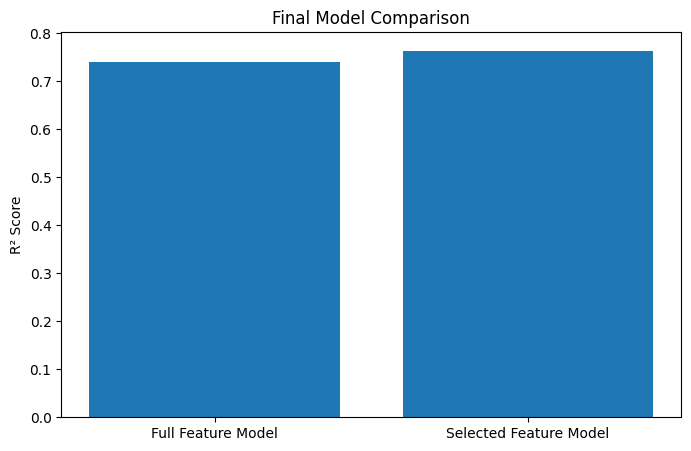

In [139]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df['Model'],
    comparison_df['R²']
)

plt.title('Final Model Comparison')

plt.ylabel('R² Score')

plt.show()